In [1]:
import numpy as np
import opendssdirect as dss
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import yadi.dss.model as dss_model
import yadi.dss.sensitivity as dss_sens
import yadi.dss.qsts as dss_qsts

In [3]:
#Setup plot aesthetics
import matplotlib
%matplotlib inline
matplotlib.rc('text', usetex=True)
matplotlib.rc('text.latex', preamble=r'\usepackage{amsmath,amssymb}')
sns.set_theme(context='paper',style='ticks')

## Using OpenDSS in Python to analyze a 3-bus, unbalanced, OpenDSS test case.

Note that a 3-phase, 3-bus case implies 9 nodes in OpenDSS.

In [4]:
#Load the case3_unbalanced file from PowerModelsDistribution.jl
case_name = 'case3_unbalanced'
cktfile = r"test_cases/{case_name}.dss".format(case_name=case_name)

### 1st Order Taylor Expansion Coefficients ("Voltage Sensitivity Matrices")

The object `dss_sens.OpenDSS_Sensitivities(cktfile)` allows you to form first-order Taylor expansion coefficients $\frac{\partial \mathbf{v}}{\partial \mathbf{p}}, \frac{\partial \mathbf{v}}{\partial \mathbf{q}}$ for any arbitrary opendss network model `ckfile`, such that
$$
\Delta \mathbf{v} \approx \frac{\partial \mathbf{v}}{\partial \mathbf{p}} \Delta \mathbf{p} + \frac{\partial \mathbf{v}}{\partial \mathbf{q}} \Delta \mathbf{q},
$$
where $\frac{\partial \mathbf{v}}{\partial \mathbf{p}}, \frac{\partial \mathbf{v}}{\partial \mathbf{q}} \in \mathbb{R}^{3n \times 3n}$, and $\Delta \mathbf{v}, \Delta \mathbf{p}, \Delta \mathbf{q} \in \mathbb{R}^{3 n}$

DSS Compiling...
DSS Running file: test_cases/case3_unbalanced.dss
DSS Compiled Circuit: 3bus_example
DSS Running file: test_cases/case3_unbalanced.dss
DSS Compiled Circuit: 3bus_example
DSS Running file: test_cases/case3_unbalanced.dss
DSS Compiled Circuit: 3bus_example
DSS Running file: test_cases/case3_unbalanced.dss
DSS Compiled Circuit: 3bus_example
DSS Running file: test_cases/case3_unbalanced.dss
DSS Compiled Circuit: 3bus_example
DSS Running file: test_cases/case3_unbalanced.dss
DSS Compiled Circuit: 3bus_example
DSS Running file: test_cases/case3_unbalanced.dss
DSS Compiled Circuit: 3bus_example
DSS Running file: test_cases/case3_unbalanced.dss
DSS Compiled Circuit: 3bus_example
DSS Running file: test_cases/case3_unbalanced.dss
DSS Compiled Circuit: 3bus_example
DSS Running file: test_cases/case3_unbalanced.dss
DSS Compiled Circuit: 3bus_example
DSS Running file: test_cases/case3_unbalanced.dss
DSS Compiled Circuit: 3bus_example
DSS Running file: test_cases/case3_unbalanced.ds

Text(0.5, 0.98, 'Voltage sensitivities without slack nodes')

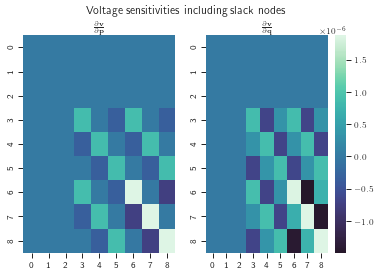

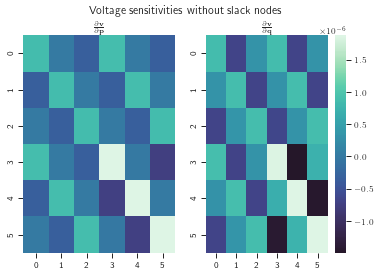

In [5]:
sens = dss_sens.DSS_Sensitivities(cktfile,verbose=False)

#Get the taylor coefficients
dvdp = sens.get_svp()
dvdq = sens.get_svq()

#Plot the matrices of sensitivity coefficients including the slack nodes
fig,axes = plt.subplots(ncols=2)
h1 = sns.heatmap(dvdp["matrix"],ax=axes[0],center=0,cmap='mako',cbar=False)
h2 = sns.heatmap(dvdq["matrix"],ax=axes[1],center=0,cmap='mako')
axes[0].set_title(r"$\frac{\partial \mathbf{v}}{\partial \mathbf{p}}$")
axes[1].set_title(r"$\frac{\partial \mathbf{v}}{\partial \mathbf{q}}$")
plt.suptitle("Voltage sensitivities including slack nodes")

#Plot the matrices of sensitivity coefficients without the slack nodes
fig,axes = plt.subplots(ncols=2)
h1 = sns.heatmap(dvdp["matrix"][3:,3:],ax=axes[0],center=0,cmap='mako',cbar=False)
h2 = sns.heatmap(dvdq["matrix"][3:,3:],ax=axes[1],center=0,cmap='mako')
axes[0].set_title(r"$\frac{\partial \mathbf{v}}{\partial \mathbf{p}}$")
axes[1].set_title(r"$\frac{\partial \mathbf{v}}{\partial \mathbf{q}}$")
plt.suptitle("Voltage sensitivities without slack nodes")

### Nodal admittance matrix

DSS Running file: test_cases/case3_unbalanced.dss
DSS Compiled Circuit: 3bus_example


Text(0.5, 1.0, 'Rectangular Nodal Voltages')

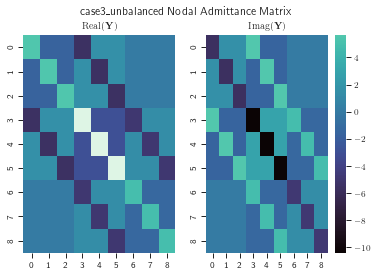

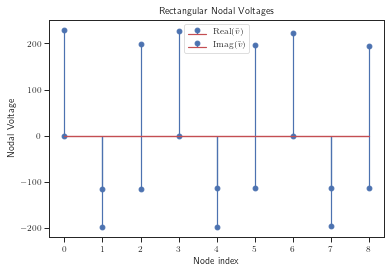

In [6]:
model = dss_model.DSS_Data(cktfile)
#Get the nodal admittance matrix and a vector of complex voltages in rectangular form.
Ynet,vnet = Y = model.get_node_ybus(True)

#Plot the admittance matrix
fig,axes = plt.subplots(ncols=2)
h1 = sns.heatmap(np.real(Ynet),ax=axes[0],center=0,cmap='mako',cbar=False)
h2 = sns.heatmap(np.imag(Ynet),ax=axes[1],center=0,cmap='mako')
axes[0].set_title(r"$\operatorname{Real}(\mathbf{Y})$")
axes[1].set_title(r"$\operatorname{Imag}(\mathbf{Y})$")
plt.suptitle(r"{case_name} Nodal Admittance Matrix".format(case_name=case_name))


#Plot the real and imaginary components of the bus voltages
plt.figure()
plt.stem(np.real(vnet),label=r"$\operatorname{Real}(\bar{v})$")
plt.stem(np.imag(vnet),label=r"$\operatorname{Imag}(\bar{v})$")
plt.legend()
plt.xlabel("Node index")
plt.ylabel("Nodal Voltage")
plt.title("Rectangular Nodal Voltages")

## Using Yadi to get timeseries data

- Parameters:
    - redirects (Circuit files/network model paths)
    - time_step (Time step of time series simulation (string))
    - simulation_steps (string) (Number of total simulation steps at time_step granularity)

In [7]:
qsts = dss_qsts.DSS_Timeseries(
    redirects=cktfile,
    time_step="15m",
    simulation_steps=24*4
    )
qsts.run()

#Nodal current injections timeseries
I = qsts.currents_mvts

#Complex power injection timeseries
S = qsts.complex_powers_mvts

#Voltage magnitude timeseries
V = qsts.voltages_mvts


/home/sam/Research/yadi/yadi/dss/qsts.py:301: UserWarning: QSTS has not been initialized. Initiailizing before run.
  warnings.warn("QSTS has not been initialized. Initiailizing before run.")


DSS Running file: test_cases/case3_unbalanced.dss
DSS Compiled Circuit: 3bus_example
Monitor type:  mon_l1_power  placed on Load  name:  l1 with errors:  
Monitor type:  mon_l1_voltage  placed on Load  name:  l1 with errors:  
Monitor type:  mon_l2_power  placed on Load  name:  l2 with errors:  
Monitor type:  mon_l2_voltage  placed on Load  name:  l2 with errors:  
Monitor type:  mon_l3_power  placed on Load  name:  l3 with errors:  
Monitor type:  mon_l3_voltage  placed on Load  name:  l3 with errors:  
QSTS Initialized, Returned:  ['', '', '']


QSTS running...: 100%|██████████| 96/96 [00:00<00:00, 10062.05it/s]


In [8]:
V

array([[ 229.99324947-5.63065772e-06j, -114.99662818-1.99179996e+02j,
        -114.99662201+1.99179999e+02j,  226.53589315-8.86663011e-01j,
        -114.63226838-1.97645725e+02j, -114.39629342+1.97162948e+02j,
         222.51339563-1.88062757e+00j, -114.19367294-1.95869767e+02j,
        -113.72107106+1.94814467e+02j],
       [ 229.99324947-5.63065937e-06j, -114.99662818-1.99179996e+02j,
        -114.99662201+1.99179999e+02j,  226.53589158-8.86663435e-01j,
        -114.63226922-1.97645725e+02j, -114.39629413+1.97162948e+02j,
         222.51339224-1.88062847e+00j, -114.19367477-1.95869768e+02j,
        -113.72107262+1.94814466e+02j],
       [ 229.99324947-5.63065938e-06j, -114.99662818-1.99179996e+02j,
        -114.99662201+1.99179999e+02j,  226.53589157-8.86663439e-01j,
        -114.63226923-1.97645725e+02j, -114.39629414+1.97162948e+02j,
         222.51339221-1.88062848e+00j, -114.19367479-1.95869768e+02j,
        -113.72107263+1.94814466e+02j],
       [ 229.99324947-5.63065938e-06j, -